In [1]:
# Автоматическая подгрузка обновлений из src
%reload_ext autoreload

# Чтобы торч не мучал warning-ами
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from datagen import *
from neuralGMM import NeuralSwitchingGMM
from utils import train_model, diagnose_training
from torch.utils.data import DataLoader
import torch.optim as optim
from data_prep import TimeSeriesDatasetWithChangePoints, create_dataloaders



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/artyomkraevskiy/opt/anaconda3/envs/neuro_EWS/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/artyomkraevskiy/opt/anaconda3/envs/neuro_EWS/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/artyomkraevskiy/opt/anaconda3/envs/neuro_EWS/lib/python3.12/site-packages/i

# Бейзлайн - Гауссовские смеси + RNN (НейроКалман для бинарного латента)

## Параметры GMM в неограниченном пространстве

Для корректного усреднения параметров мы работаем в **неограниченных пространствах**:

| Параметр | Ограничение | Внутреннее представление | Преобразование |
|----------|-------------|--------------------------|----------------|
| Среднее $\mu_k$ | $\mathbb{R}$ | $\tilde{\mu}_k \in \mathbb{R}$ | $\mu_k = \tilde{\mu}_k$ |
| Дисперсия $\sigma_k^2$ | $\mathbb{R}^+$ | $\tilde{v}_k = \log \sigma_k^2 \in \mathbb{R}$ | $\sigma_k = \exp(\tilde{v}_k / 2)$ |
| Веса $\pi_k$ | $\sum \pi_k = 1$ | $\tilde{l}_k \in \mathbb{R}$ (логиты) | $\pi_k = \operatorname{Softmax}(\tilde{l})_k$ |

## Рекуррентное обновление состояния

Итоговые параметры в момент времени $t$ вычисляются как взвешенная комбинация:

$$
\tilde{\theta}_t^{\text{final}} = \alpha_t \cdot \tilde{\theta}_t^{\text{new}} + (1 - \alpha_t) \cdot \tilde{\theta}_{t-1}^{\text{final}}
$$

где $\tilde{\theta}$ — параметры в неограниченном пространстве, а $\alpha_t \in (0, 1)$ — вероятность точки изменения.

В развёрнутом виде для каждого типа параметров:

$$
\begin{aligned}
\tilde{\mu}_t^{\text{final}} &= \alpha_t \cdot \tilde{\mu}_t^{\text{new}} + (1 - \alpha_t) \cdot \tilde{\mu}_{t-1}^{\text{final}} \\
\tilde{v}_t^{\text{final}} &= \alpha_t \cdot \tilde{v}_t^{\text{new}} + (1 - \alpha_t) \cdot \tilde{v}_{t-1}^{\text{final}} \\
\tilde{l}_t^{\text{final}} &= \alpha_t \cdot \tilde{l}_t^{\text{new}} + (1 - \alpha_t) \cdot \tilde{l}_{t-1}^{\text{final}}
\end{aligned}
$$

## Правдоподобие GMM

Плотность вероятности в момент времени $t$ задаётся смесью гауссиан:

$$
p(x_t | \theta_t) = \sum_{k=1}^{K} \pi_{t,k} \cdot \mathcal{N}(x_t | \mu_{t,k}, \sigma_{t,k}^2)
$$

где гауссова плотность:

$$
\mathcal{N}(x | \mu, \sigma^2) = \frac{1}{\sqrt{2\pi}\sigma} \exp\left(-\frac{1}{2} \left(\frac{x - \mu}{\sigma}\right)^2\right)
$$

Для численной устойчивости мы вычисляем логарифм правдоподобия, используя приём log-sum-exp:

$$
\log p(x_t | \theta_t) = \operatorname{LogSumExp}_{k=1}^{K} \left( \log \pi_{t,k} + \log \mathcal{N}(x_t | \mu_{t,k}, \sigma_{t,k}^2) \right)
$$

## Функция потерь

Общая функция потерь состоит из трёх компонент:

$$
\mathcal{L} = \mathcal{L}_{\text{NLL}} + \lambda \cdot \mathcal{L}_{\text{sparsity}} + \beta \cdot \mathcal{L}_{\text{entropy}}
$$

### Отрицательное логарифмическое правдоподобие:
$$
\mathcal{L}_{\text{NLL}} = -\frac{1}{T} \sum_{t=1}^{T} \log p(x_t | \theta_t)
$$

### Штраф за разреженность:
$$
\mathcal{L}_{\text{sparsity}} = \frac{1}{T} \sum_{t=1}^{T} \alpha_t
$$

### Штраф за бинарную энтропию:
$$
\mathcal{L}_{\text{entropy}} = \frac{1}{T} \sum_{t=1}^{T} H(\alpha_t)
$$

где бинарная энтропия определяется как:

$$
H(\alpha) = -\left[ \alpha \log \alpha + (1 - \alpha) \log (1 - \alpha) \right]
$$

---

# Архитектура нейронной сети

## RNN-кодировщик

Скрытое состояние в момент времени $t$ вычисляется следующим образом:

$$
h_t = \text{RNN}(x_t, h_{t-1}; \phi_{\text{rnn}})
$$

где $\phi_{\text{rnn}}$ — параметры RNN.

## Детектор точек изменения

$$
\alpha_t = \operatorname{Sigmoid}(W_{\alpha} h_t + b_{\alpha})
$$

## Выходные головы для параметров GMM

$$
\begin{aligned}
\tilde{\mu}_t^{\text{new}} &= W_{\mu} h_t + b_{\mu} \\
\tilde{v}_t^{\text{new}} &= W_{v} h_t + b_{v} \\
\tilde{l}_t^{\text{new}} &= W_{l} h_t + b_{l}
\end{aligned}
$$

---

# Инференс и обнаружение точек изменения

## Идентификация точек изменения

После обучения точки изменения определяются пороговым значением $\alpha_t$:

$$
z_t = \mathbb{I}(\alpha_t > \tau)
$$

где $\tau \in (0, 1)$ — порог (обычно $\tau = 0.5$), а $\mathbb{I}(\cdot)$ — индикаторная функция.

## Постобработка

Для удаления слишком близко расположенных точек изменения применяется подавление немаксимумов:

$$
z_t^{\text{final}} = 
\begin{cases}
1, & \text{если } z_t = 1 \text{ и } \sum_{j=t-d}^{t-1} z_j = 0 \\
0, & \text{иначе}
\end{cases}
$$

где $d$ — минимальное расстояние между точками изменения.

---

# Алгоритм обучения

**Вход:** временной ряд $X = \{x_1, \dots, x_T\}$, гиперпараметры $\lambda, \beta$  
**Инициализация:** $\theta_0^{\text{final}}$ (обучаемые параметры)

Для epoch = 1 до $N_{\text{epochs}}$:
   Для батча $X^{(b)}$ в DataLoader:

1. Вычислить скрытые состояния: $h_t = \text{RNN}(x_t, h_{t-1})$
2. Вычислить вероятности изменения: $\alpha_t = \operatorname{Sigmoid}(W_{\alpha} h_t + b_{\alpha})$
3. Вычислить новые параметры: $\tilde{\theta}_t^{\text{new}} = \text{MLP}(h_t)$
4. Обновить состояние: $\tilde{\theta}_t^{\text{final}} = \alpha_t \tilde{\theta}_t^{\text{new}} + (1-\alpha_t) \tilde{\theta}_{t-1}^{\text{final}}$
5. Преобразовать в допустимые параметры: $\theta_t = \text{Transform}(\tilde{\theta}_t^{\text{final}})$
6. Вычислить правдоподобие: $p(x_t | \theta_t)$ (используя плотность GMM)
7. Вычислить потери: $\mathcal{L}$ (общая функция потерь)
8. Обновить параметры с помощью градиентного спуска

**Выход:** обученная модель

---

# Гиперпараметры

| Параметр | Рекомендуемый диапазон | Описание |
|----------|------------------------|----------|
| $\text{hidden\_dim}$ | 32–128 | Размерность скрытого состояния RNN |
| $n_{\text{components}}$ | 2–5 | Количество компонент GMM |
| $\lambda$ | 0.001–0.1 | Коэффициент регуляризации разреженности |
| $\beta$ | 0.0001–0.01 | Коэффициент бинарной энтропии |
| $\tau$ | 0.3–0.7 | Порог обнаружения точки изменения |
| $d_{\text{min}}$ | 3–10 | Минимальное расстояние между точками изменения |

---

# Вычисление градиентов

Градиент функции потерь по $\alpha_t$:

$$
\frac{\partial \mathcal{L}}{\partial \alpha_t} = 
\underbrace{\frac{\partial \mathcal{L}_{\text{NLL}}}{\partial \theta_t} \cdot \frac{\partial \theta_t}{\partial \alpha_t}}_{\text{через правдоподобие}} +
\underbrace{\lambda}_{\text{разреженность}} +
\underbrace{\beta \cdot \frac{\partial H(\alpha_t)}{\partial \alpha_t}}_{\text{энтропия}}
$$

где:

$$
\frac{\partial H(\alpha)}{\partial \alpha} = -\log \alpha + \log (1 - \alpha)
$$

и:

$$
\frac{\partial \theta_t}{\partial \alpha_t} = \tilde{\theta}_t^{\text{new}} - \tilde{\theta}_{t-1}^{\text{final}}
$$


# Нотация

| Символ | Значение |
|--------|----------|
| $x_t$ | Наблюдение в момент времени $t$ |
| $h_t$ | Скрытое состояние RNN в момент времени $t$ |
| $\alpha_t$ | Вероятность точки изменения в момент $t$ |
| $\theta_t$ | Параметры GMM в момент $t$ |
| $\mu_{t,k}$ | Среднее $k$-й компоненты GMM в момент $t$ |
| $\sigma_{t,k}$ | Стандартное отклонение $k$-й компоненты |
| $\pi_{t,k}$ | Вес $k$-й компоненты GMM |
| $K$ | Количество компонент GMM |
| $T$ | Длина последовательности |
| $B$ | Размер батча |
| $\lambda$ | Коэффициент регуляризации разреженности |
| $\beta$ | Коэффициент регуляризации энтропии |
| $\tau$ | Порог обнаружения |

---

In [2]:
means = np.array([[-10, 0, 10],
                  [-15, 0, 15]])

variances = np.array([[10, 3, 10],
              [10, 3, 10]])

weights = np.array([[0.25, 0.5, 0.25],
              [0.1, 0.8, 0.1]])

generator = GMMChangePointGenerator(10_000, 
                                    [5000], 
                                    3, 
                                    means,
                                    variances,
                                    weights
                                    )

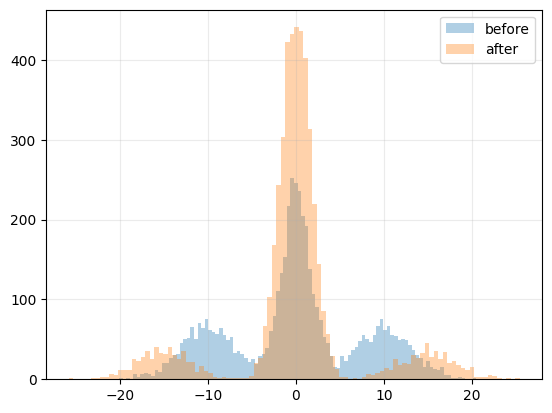

In [3]:
obs = generator.generate()
data, regimes = obs[0], obs[1]

plt.hist(data[:5000], bins =100, label = 'before', alpha=0.35)
plt.hist(data[5000:], bins =100, label = 'after', alpha=0.35)
plt.legend()
plt.grid(alpha=0.25)
plt.show()

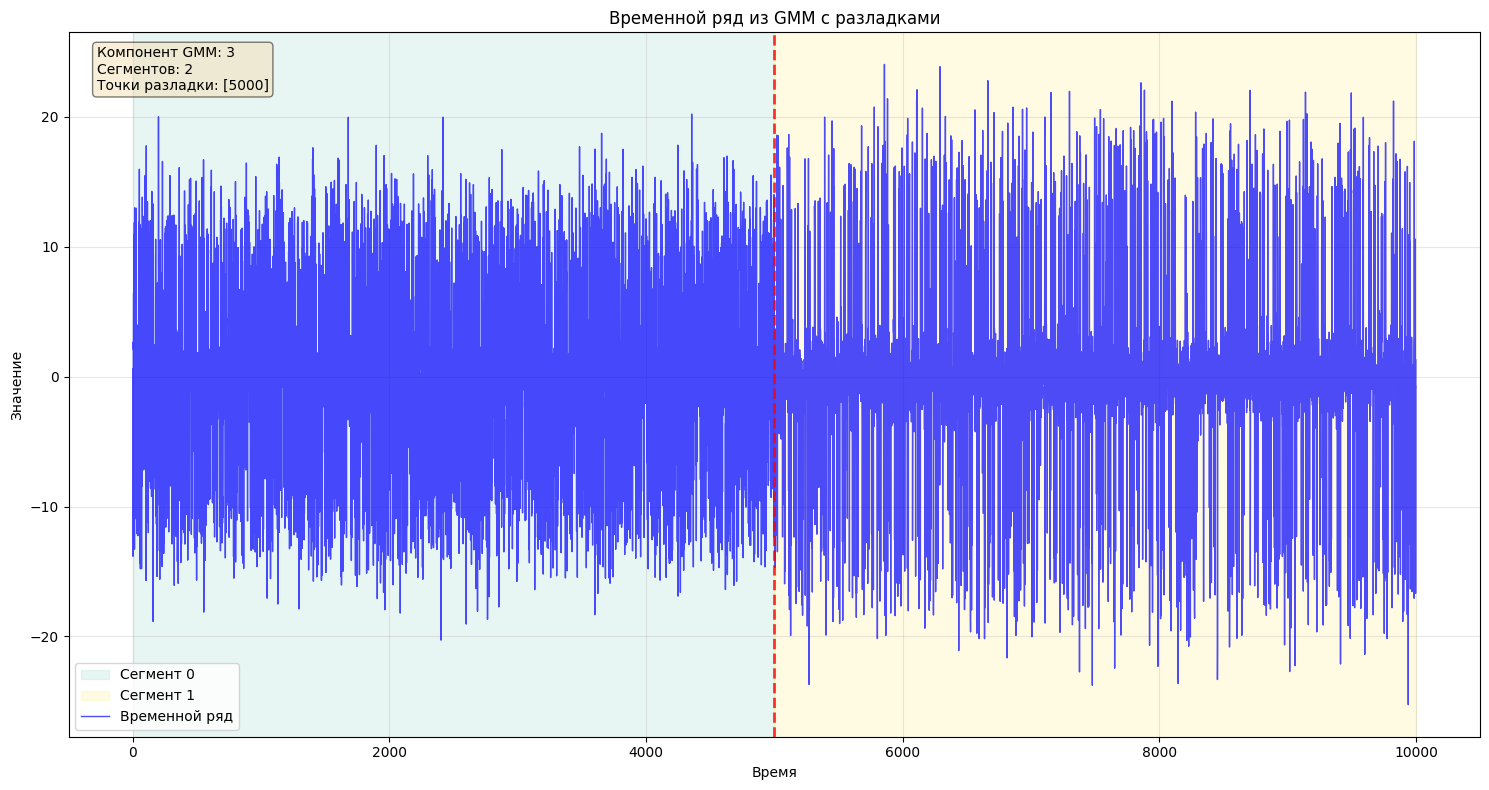

(<Figure size 1500x800 with 1 Axes>,
 <Axes: title={'center': 'Временной ряд из GMM с разладками'}, xlabel='Время', ylabel='Значение'>)

In [4]:
generator.visualize()

In [5]:
changepoints = np.zeros(10_000)
changepoints[5000] = 1
dataset = TimeSeriesDatasetWithChangePoints(data, 
                                            changepoints, 
                                            100,
                                            1)
loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    drop_last=True,
    num_workers=0,
    pin_memory=False,
)


Dataset создан: 9901 последовательностей длиной 100
Статистика: mean=-0.0250, std=7.4062


In [6]:
model = NeuralSwitchingGMM(
    1,
    32,
    3,
    0.001,
    0.03,
)

optimizer = optim.AdamW(  # AdamW лучше отделяет weight_decay от градиентов
        model.parameters(),
        lr=1e-3,
        betas=(0.9, 0.99),
        eps=1e-8,
        weight_decay=1e-5,
    )

In [7]:
train_model(model,
            loader,
            optimizer,
            25,
            device='cpu'
            )

Epoch 10/25: Loss=nan, NLL=nan, Sparsity=nan


KeyboardInterrupt: 